# RELIM — Thực nghiệm & Đánh giá (Phần 3.4.1)

Notebook này thực hiện các thực nghiệm đánh giá thuật toán RELIM trên 5 bộ dữ liệu benchmark:
Chess, Mushroom, Retail, Accidents, T10I4D100K.

## Mục lục
1. Setup môi trường
2. Clone code & chuẩn bị dữ liệu
3. Kiểm tra tính đúng đắn (Correctness vs SPMF)
4. Thời gian chạy theo minsup
   - 4.1 Đồ thị 1 — Runtime vs Minsup (RELIM nhóm)
   - 4.2 Thu thập SPMF runtime
   - 4.3 Đồ thị 5 — So sánh RELIM nhóm vs SPMF
5. Số lượng frequent itemsets theo minsup (Đồ thị 2)
6. Sử dụng bộ nhớ
   - 6.1 Đồ thị 6 — Bộ nhớ Basic (L1) vs Optimized (L3)
7. Khả năng mở rộng — Đồ thị 3 (Scalability)
8. Ảnh hưởng độ dài giao dịch — Đồ thị 4

---


## 1. Setup môi trường

Cài Julia thông qua `juliaup` và các package cần thiết.
`Plots.jl` không được cài vì gây xung đột `Qt6Base_jll` trên Kaggle — toàn bộ đồ thị sẽ được vẽ bằng `matplotlib` (Python).

In [1]:
%%bash
# Xóa config cũ của juliaup từ lần chạy trước
rm -rf /root/.julia/juliaup/juliaup.json

# Cài lại juliaup
curl -fsSL https://install.julialang.org | sh -s -- --yes
export PATH="$HOME/.juliaup/bin:$PATH"
julia --version

julia -e 'using Pkg; Pkg.add("Combinatorics"); println("Combinatorics OK")'
# Cài từng package riêng lẻ để tránh conflict
julia -e 'using Pkg; Pkg.add("BenchmarkTools"); println("BenchmarkTools OK")'
julia -e 'using Pkg; Pkg.add("CSV"); println("CSV OK")'
julia -e 'using Pkg; Pkg.add("DataFrames"); println("DataFrames OK")'
julia -e 'using Pkg; Pkg.add("Statistics"); println("Statistics OK")'
julia -e 'using Pkg; Pkg.add("StatsBase"); println("StatsBase OK")'
echo "=== ALL DONE ==="

Welcome to Julia!

This will download and install the official Julia Language distribution
and its version manager Juliaup.

Juliaup will be installed into the Juliaup home directory, located at:

  /root/.juliaup

The julia, juliaup and other commands will be added to
Juliaup's bin directory, located at:

  /root/.juliaup/bin

This path will then be added to your PATH environment variable by
modifying the profile files located at:

  /root/.bashrc
  /root/.profile

Julia will look for a new version of Juliaup itself every 1440 minutes when you start julia.

You can uninstall at any time with juliaup self uninstall and these
changes will be reverted.

Now installing Juliaup
Julia was successfully installed on your system.

Depending on which shell you are using, run one of the following
commands to reload the PATH environment variable:

  . /root/.bashrc
  . /root/.profile

julia version 1.12.6
=== ALL DONE ===



info: downloading installer
    Checking for new Julia versions
  Installing Julia 1.12.6+0.x64.linux.gnu
         Add Installed Julia channel 'release'
   Configure Default Julia version set to 'release'.
    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
ERROR: version 6.10.2+1 of package Qt6Base_jll is not available. Available versions: 6.0.3+0, 6.0.3+1, 6.3.0+0, 6.3.0+1, 6.4.1+0, 6.4.1+1, 6.4.2+0, 6.4.2+1, 6.4.2+2, 6.4.2+3, 6.5.2+0, 6.5.2+1, 6.5.2+2, 6.5.3+0, 6.5.3+1, 6.7.0+0, 6.7.0+1, 6.7.1+0, 6.7.1+1, 6.8.1+0, 6.8.2+0, 6.8.2+1, 6.8.2+2, 6.10.2+2
Stacktrace:
  [1] pkgerror(msg::String)
    @ Pkg.Types ~/.julia/juliaup/julia-1.12.6+0.x64.linux.gnu/share/julia/stdlib/v1.12/Pkg/src/Types.jl:68
  [2] resolve_versions!(env::Pkg.Types.EnvCache, registries::Vector{Pkg.Registry.RegistryInstance}, pkgs::Vector{PackageSpec}, julia_version::VersionNumber, installed_only::Bool)
    @ Pkg.Operations ~/.julia/juliaup/julia-1.12.6+0.x64.linux.gnu/share/

## 2. Copy dữ liệu vào thư mục làm việc

Copy toàn bộ source code và các file benchmark dataset từ Kaggle input vào `/kaggle/working/relim`.


In [2]:
%%bash
# Clone toàn bộ repo (bao gồm cả data/benchmark/) từ GitHub
rm -rf /kaggle/working/relim
git clone https://github.com/Thinh59/relim_datamining_julia.git /kaggle/working/relim

echo "=== Cấu trúc relim ==="
ls /kaggle/working/relim/
echo "=== src/ ==="
ls /kaggle/working/relim/src/
echo "=== data/benchmark/ ==="
ls /kaggle/working/relim/data/benchmark/


=== Cấu trúc relim ===
data
docs
frequent_itemsets.txt
Manifest.toml
notebooks
Project.toml
README.md
spmf.jar
src
tests
=== src/ ===
algorithm
main.jl
structures.jl
utils.jl
=== data/benchmark/ ===
accidents.txt
chess.txt
mushroom.txt
retail.txt
T10I4D100K.txt


Cloning into '/kaggle/working/relim'...


### 2.1 Cài Java 21

SPMF được compile bằng Java 21 (class file version 65.0), trong khi Kaggle mặc định chỉ có Java 17 (hỗ trợ tối đa 61.0) → cần cài Java 21 thủ công từ Adoptium vì `apt-get` trên Kaggle không có package này.

Lỗi nếu dùng Java 17: `UnsupportedClassVersionError: class file version 65.0`

In [5]:
%%bash
# Download Java 21 từ Adoptium (không cần apt)
wget -q https://github.com/adoptium/temurin21-binaries/releases/download/jdk-21.0.3%2B9/OpenJDK21U-jdk_x64_linux_hotspot_21.0.3_9.tar.gz -O /tmp/jdk21.tar.gz

# Giải nén
mkdir -p /opt/jdk21
tar -xzf /tmp/jdk21.tar.gz -C /opt/jdk21 --strip-components=1

# Set JAVA_HOME
export JAVA_HOME=/opt/jdk21
export PATH=$JAVA_HOME/bin:$PATH
java -version

# Test spmf
java -jar /kaggle/working/relim/spmf.jar 2>&1 | head -3

Exception in thread "main" java.awt.HeadlessException: 
No X11 DISPLAY variable was set,
or no headful library support was found,


openjdk version "21.0.3" 2024-04-16 LTS
OpenJDK Runtime Environment Temurin-21.0.3+9 (build 21.0.3+9-LTS)
OpenJDK 64-Bit Server VM Temurin-21.0.3+9 (build 21.0.3+9-LTS, mixed mode, sharing)


## 3. Kiểm tra tính đúng đắn (Correctness)

So sánh kết quả của cài đặt nhóm với công cụ SPMF (chuẩn tham chiếu) trên cả 5 dataset.

Với mỗi dataset, chạy RELIM ở 2 mức minsup khác nhau và đối chiếu:
- Số lượng frequent itemsets tìm được
- Giá trị support của từng itemset

**Kết quả mong đợi:** Match rate = 100% trên tất cả dataset.

> Lưu ý: `T10I4D100K` ở minsup cao (abs=5000) ra 0 itemsets — đây là kết quả đúng vì dataset này thưa, không có itemset nào đủ phổ biến ở ngưỡng đó. SPMF cũng trả về 0.

In [9]:
%%bash
export JAVA_HOME=/opt/jdk21
export PATH=$JAVA_HOME/bin:$PATH
export PATH="$HOME/.juliaup/bin:$PATH"
cd /kaggle/working/relim

julia --project=. -e '
include("src/algorithm/relim.jl")

txns = [[1,3,4],[2,3,5],[1,2,3,5],[2,5]]
result = relim(txns, 2; relative=false)
println("Toy example: found ", length(result), " itemsets (expected 9)")

datasets = [
    ("chess",      "data/benchmark/chess.txt",      [1598, 2557]),
    ("mushroom",   "data/benchmark/mushroom.txt",    [812,  4062]),
    ("retail",     "data/benchmark/retail.txt",      [882,  4408]),
    ("accidents",  "data/benchmark/accidents.txt",   [170091, 255137]),
    ("T10I4D100K", "data/benchmark/T10I4D100K.txt",  [1000, 5000]),
]

println("\n=== CORRECTNESS vs SPMF ===")
println(rpad("Dataset",14), rpad("Minsup",10), rpad("Our",10), rpad("SPMF",10), "Match%")
println("-"^55)

for (name, path, minsups) in datasets
    if !isfile(path)
        println(rpad(name,14), "  SKIP - file not found")
        continue
    end
    local txns = load_spmf(path)
    txns = [sort(unique(t)) for t in txns if !isempty(t)]
    n = length(txns)

    for ms_abs in minsups
        local our = relim(txns, ms_abs; relative=false)

        ms_pct = (ms_abs - 0.01) / n
        clean_file = "clean_$(name).txt"
        open(clean_file, "w") do io
            for t in txns; println(io, join(t, " ")); end
        end
        spmf_out = "spmf_out_$(name)_$(ms_abs).txt"

        spmf_count = 0
        try
            run(pipeline(ignorestatus(`java -jar /kaggle/working/relim/spmf.jar run Relim $clean_file $spmf_out $ms_pct`),
                         stdout=devnull, stderr=devnull))
            spmf_count = isfile(spmf_out) ? count(l -> occursin("#SUP:", l), readlines(spmf_out)) : 0
        catch e
            spmf_count = -1
        end

        match_pct = spmf_count <= 0 ? "N/A" : string(round(length(our)/spmf_count*100, digits=1), "%")
        println(rpad(name,14), rpad(ms_abs,10), rpad(length(our),10), rpad(spmf_count,10), match_pct)
        rm(clean_file, force=true)
        rm(spmf_out,   force=true)
    end
end
'

Toy example: found 9 itemsets (expected 9)

=== CORRECTNESS vs SPMF ===
Dataset       Minsup    Our       SPMF      Match%
-------------------------------------------------------
chess         1598      1272932   1272932   100.0%
chess         2557      8227      8227      100.0%
mushroom      812       605231    605231    100.0%
mushroom      4062      179       179       100.0%
retail        882       17646     17646     100.0%
retail        4408      2798      2798      100.0%
accidents     170091    8059      8059      100.0%
accidents     255137    313       313       100.0%
T10I4D100K    1000      106       106       100.0%
T10I4D100K    5000      0         0         N/A


## 4. Thời gian chạy theo minsup

Đo thời gian chạy (ms) của RELIM trên từng dataset với 7 mức minsup khác nhau (từ cao xuống thấp).

**Lưu ý về ngưỡng minsup:**
- Chess, Accidents: dataset **dày** (dense) — minsup phải cao (≥ 0.70) để tránh bùng nổ itemsets gây tràn RAM.
- Retail, T10I4D100K: dataset **thưa** (sparse) — minsup thấp vẫn cho số itemsets hợp lý.
- Mushroom: mật độ trung bình, minsup từ 0.10–0.60.

Kết quả được lưu vào `runtime_results.csv` để vẽ đồ thị ở bước tiếp theo.

In [10]:
%%bash
export PATH="$HOME/.juliaup/bin:$PATH"
cd /kaggle/working/relim

julia --project=. -e '
include("src/algorithm/relim.jl")

f = open("/kaggle/working/runtime_results.csv","w")
println(f, "dataset,minsup,runtime_ms,n_itemsets")

println("--- chess ---")
let txns = load_spmf("data/benchmark/chess.txt")
    relim(txns[1:200], 0.9)
    for ms in [0.99, 0.95, 0.90, 0.85, 0.80, 0.75, 0.70]
        t = @elapsed res = relim(txns, ms; relative=true)
        println("  minsup=$ms -> $(round(t*1000,digits=2))ms, $(length(res)) itemsets")
        println(f, "chess,$ms,$(round(t*1000,digits=2)),$(length(res))")
    end
end

println("--- mushroom ---")
let txns = load_spmf("data/benchmark/mushroom.txt")
    relim(txns[1:200], 0.9)
    for ms in [0.60, 0.50, 0.40, 0.30, 0.20, 0.15, 0.10]
        t = @elapsed res = relim(txns, ms; relative=true)
        println("  minsup=$ms -> $(round(t*1000,digits=2))ms, $(length(res)) itemsets")
        println(f, "mushroom,$ms,$(round(t*1000,digits=2)),$(length(res))")
    end
end

println("--- retail ---")
let txns = load_spmf("data/benchmark/retail.txt")
    relim(txns[1:200], 0.9)
    for ms in [0.10, 0.05, 0.03, 0.02, 0.01, 0.005, 0.002]
        t = @elapsed res = relim(txns, ms; relative=true)
        println("  minsup=$ms -> $(round(t*1000,digits=2))ms, $(length(res)) itemsets")
        println(f, "retail,$ms,$(round(t*1000,digits=2)),$(length(res))")
    end
end

println("--- accidents ---")
let txns = load_spmf("data/benchmark/accidents.txt")
    relim(txns[1:200], 0.9)
    for ms in [0.99, 0.95, 0.90, 0.85, 0.80, 0.75, 0.70]
        t = @elapsed res = relim(txns, ms; relative=true)
        println("  minsup=$ms -> $(round(t*1000,digits=2))ms, $(length(res)) itemsets")
        println(f, "accidents,$ms,$(round(t*1000,digits=2)),$(length(res))")
    end
end

println("--- T10I4D100K ---")
let txns = load_spmf("data/benchmark/T10I4D100K.txt")
    relim(txns[1:200], 0.9)
    for ms in [0.10, 0.05, 0.03, 0.02, 0.01, 0.008, 0.006]
        t = @elapsed res = relim(txns, ms; relative=true)
        println("  minsup=$ms -> $(round(t*1000,digits=2))ms, $(length(res)) itemsets")
        println(f, "T10I4D100K,$ms,$(round(t*1000,digits=2)),$(length(res))")
    end
end

close(f)
println("Done. Saved runtime_results.csv")
'

--- chess ---
  minsup=0.99 -> 4.55ms, 9 itemsets
  minsup=0.95 -> 6.59ms, 77 itemsets
  minsup=0.9 -> 21.07ms, 622 itemsets
  minsup=0.85 -> 70.92ms, 2669 itemsets
  minsup=0.8 -> 197.25ms, 8227 itemsets
  minsup=0.75 -> 468.64ms, 20993 itemsets
  minsup=0.7 -> 1392.54ms, 48731 itemsets
--- mushroom ---
  minsup=0.6 -> 11.74ms, 51 itemsets
  minsup=0.5 -> 19.68ms, 163 itemsets
  minsup=0.4 -> 38.24ms, 505 itemsets
  minsup=0.3 -> 117.5ms, 2587 itemsets
  minsup=0.2 -> 2038.37ms, 53337 itemsets
  minsup=0.15 -> 1371.85ms, 99071 itemsets
  minsup=0.1 -> 7221.41ms, 600817 itemsets
--- retail ---
  minsup=0.1 -> 722.49ms, 2510 itemsets
  minsup=0.05 -> 860.44ms, 5682 itemsets
  minsup=0.03 -> 1056.06ms, 10499 itemsets
  minsup=0.02 -> 1812.25ms, 15239 itemsets
  minsup=0.01 -> 1537.57ms, 32442 itemsets
  minsup=0.005 -> 2112.73ms, 96920 itemsets
  minsup=0.002 -> 12829.13ms, 590562 itemsets
--- accidents ---
  minsup=0.99 -> 571.31ms, 7 itemsets
  minsup=0.95 -> 776.46ms, 15 itemsets
  mi

### 4.1 Đồ thị thời gian chạy theo minsup

Vẽ đường cong runtime (ms) theo minsup giảm dần cho từng dataset.

**Nhận xét:** Khi minsup giảm, số itemsets tăng theo hàm mũ kéo theo thời gian chạy tăng phi tuyến. Dataset dày (Chess, Accidents) nhạy cảm hơn nhiều so với dataset thưa (Retail, T10I4D100K).

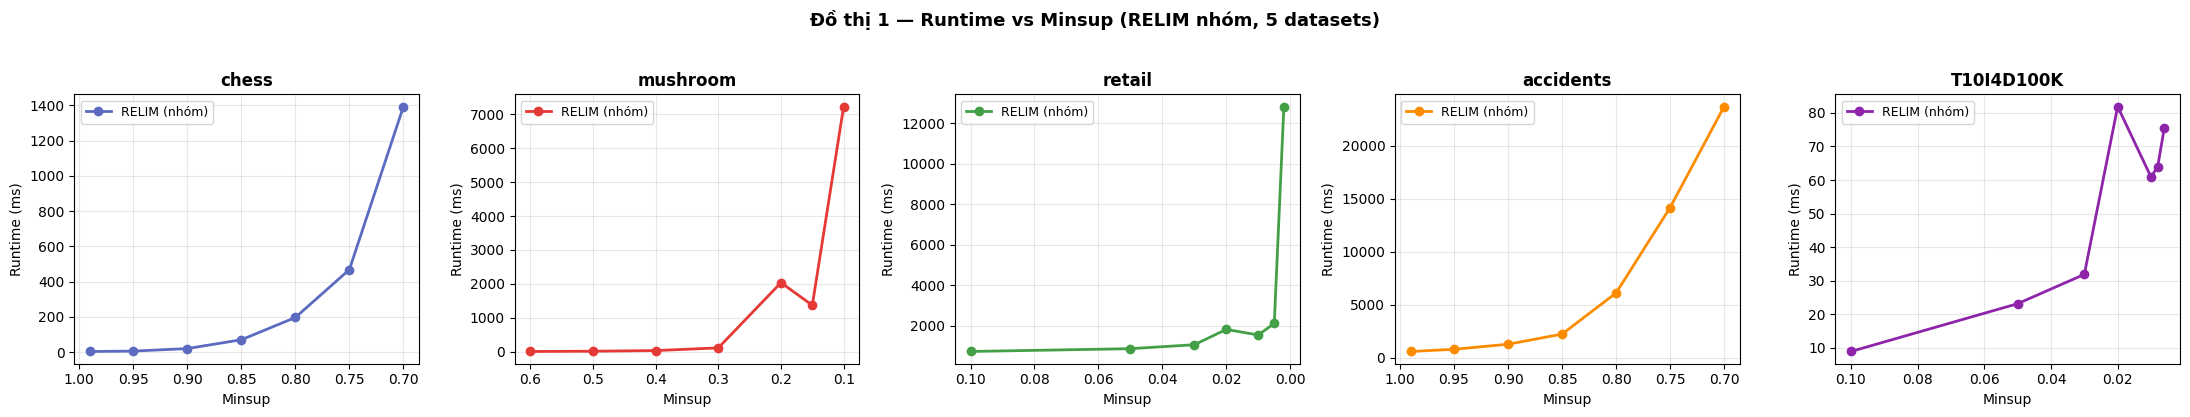

Saved: runtime_vs_minsup.png


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv("/kaggle/working/runtime_results.csv")

COLORS = ["#5C6BC0", "#E53935", "#43A047", "#FB8C00", "#8E24AA"]
datasets = df["dataset"].unique()
fig, axes = plt.subplots(1, len(datasets), figsize=(22, 4), sharey=False)

for ax, name, color in zip(axes, datasets, COLORS):
    sub = df[df["dataset"] == name].sort_values("minsup", ascending=False)
    ax.plot(sub["minsup"], sub["runtime_ms"], marker="o", linewidth=2, color=color, label="RELIM (nhóm)")
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Minsup", fontsize=10)
    ax.set_ylabel("Runtime (ms)", fontsize=10)
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle("Đồ thị 1 — Runtime vs Minsup (RELIM nhóm, 5 datasets)",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("/kaggle/working/runtime_vs_minsup.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: runtime_vs_minsup.png")


### 4.2 Thu thập runtime SPMF để so sánh (Đồ thị 5)

Chạy SPMF Java với cùng dataset và minsup, ghi lại thời gian thực thi từ output SPMF.
Kết quả ghép vào `runtime_results_spmf.csv` để vẽ so sánh.

In [16]:
%%bash
export JAVA_HOME=/opt/jdk21
export PATH=$JAVA_HOME/bin:$PATH
export PATH="$HOME/.juliaup/bin:$PATH"
cd /kaggle/working/relim

python3 - << 'EOF'
import subprocess, os, re

DATASETS = [
    ("chess",      "data/benchmark/chess.txt",      [0.99,0.95,0.90,0.85,0.80,0.75,0.70]),
    ("mushroom",   "data/benchmark/mushroom.txt",    [0.60,0.50,0.40,0.30,0.20,0.15,0.10]),
    ("retail",     "data/benchmark/retail.txt",      [0.10,0.05,0.03,0.02,0.01,0.005,0.002]),
    ("accidents",  "data/benchmark/accidents.txt",   [0.99,0.95,0.90,0.85,0.80,0.75,0.70]),
    ("T10I4D100K", "data/benchmark/T10I4D100K.txt",  [0.10,0.05,0.03,0.02,0.01,0.008,0.006]),
]
SPMF_JAR = "/kaggle/working/relim/spmf.jar"

# Kế thừa PATH/JAVA_HOME từ môi trường bash bên ngoài
env = os.environ.copy()
env["JAVA_HOME"] = "/opt/jdk21"
env["PATH"]      = "/opt/jdk21/bin:" + env.get("PATH", "")

rows = []
for name, path, minsups in DATASETS:
    if not os.path.isfile(path):
        print(f"SKIP {name} (file not found)")
        continue
    for ms in minsups:
        out_f = f"/tmp/spmf_{name}_{ms}.txt"
        cmd = ["java", "-jar", SPMF_JAR, "run", "Relim", path, out_f, str(ms)]
        try:
            result = subprocess.run(cmd, capture_output=True, text=True, timeout=120, env=env)
            #m = re.search(r'Algorithm runtime:\s*(\d+(?:\.\d+)?)', result.stdout + result.stderr)
            m = re.search(r'Total time ~:\s*(\d+(?:\.\d+)?)', result.stdout + result.stderr)
            rt = float(m.group(1)) if m else -1
            rows.append(f"{name},{ms},{rt}")
            print(f"  {name} minsup={ms}: SPMF={rt}ms")
        except Exception as e:
            rows.append(f"{name},{ms},-1")
            print(f"  {name} minsup={ms}: ERROR {e}")
        if os.path.exists(out_f): os.remove(out_f)

with open("/kaggle/working/runtime_spmf.csv", "w") as f:
    f.write("dataset,minsup,spmf_ms\n")
    f.write("\n".join(rows))
print("Saved runtime_spmf.csv")
EOF

  chess minsup=0.99: SPMF=66.0ms
  chess minsup=0.95: SPMF=75.0ms
  chess minsup=0.9: SPMF=92.0ms
  chess minsup=0.85: SPMF=116.0ms
  chess minsup=0.8: SPMF=136.0ms
  chess minsup=0.75: SPMF=184.0ms
  chess minsup=0.7: SPMF=291.0ms
  mushroom minsup=0.6: SPMF=124.0ms
  mushroom minsup=0.5: SPMF=100.0ms
  mushroom minsup=0.4: SPMF=148.0ms
  mushroom minsup=0.3: SPMF=141.0ms
  mushroom minsup=0.2: SPMF=252.0ms
  mushroom minsup=0.15: SPMF=489.0ms
  mushroom minsup=0.1: SPMF=1058.0ms
  retail minsup=0.1: SPMF=567.0ms
  retail minsup=0.05: SPMF=662.0ms
  retail minsup=0.03: SPMF=648.0ms
  retail minsup=0.02: SPMF=763.0ms
  retail minsup=0.01: SPMF=860.0ms
  retail minsup=0.005: SPMF=1019.0ms
  retail minsup=0.002: SPMF=1726.0ms
  accidents minsup=0.99: SPMF=1124.0ms
  accidents minsup=0.95: SPMF=1068.0ms
  accidents minsup=0.9: SPMF=1148.0ms
  accidents minsup=0.85: SPMF=1130.0ms
  accidents minsup=0.8: SPMF=1235.0ms
  accidents minsup=0.75: SPMF=1313.0ms
  accidents minsup=0.7: SPMF=1294.

### 4.3 Đồ thị 5 — So sánh RELIM nhóm vs SPMF (cùng dataset, cùng minsup)

Vẽ 2 đường cong trên cùng subplot cho từng dataset:
- **Xanh dương:** RELIM nhóm (Julia)
- **Đỏ:** SPMF reference (Java)

> Lưu ý: SPMF Java có chi phí JVM startup nên với dataset nhỏ có thể chậm hơn; với dataset lớn (Chess, Accidents) SPMF thường nhanh hơn do được tối ưu JIT nhiều hơn.

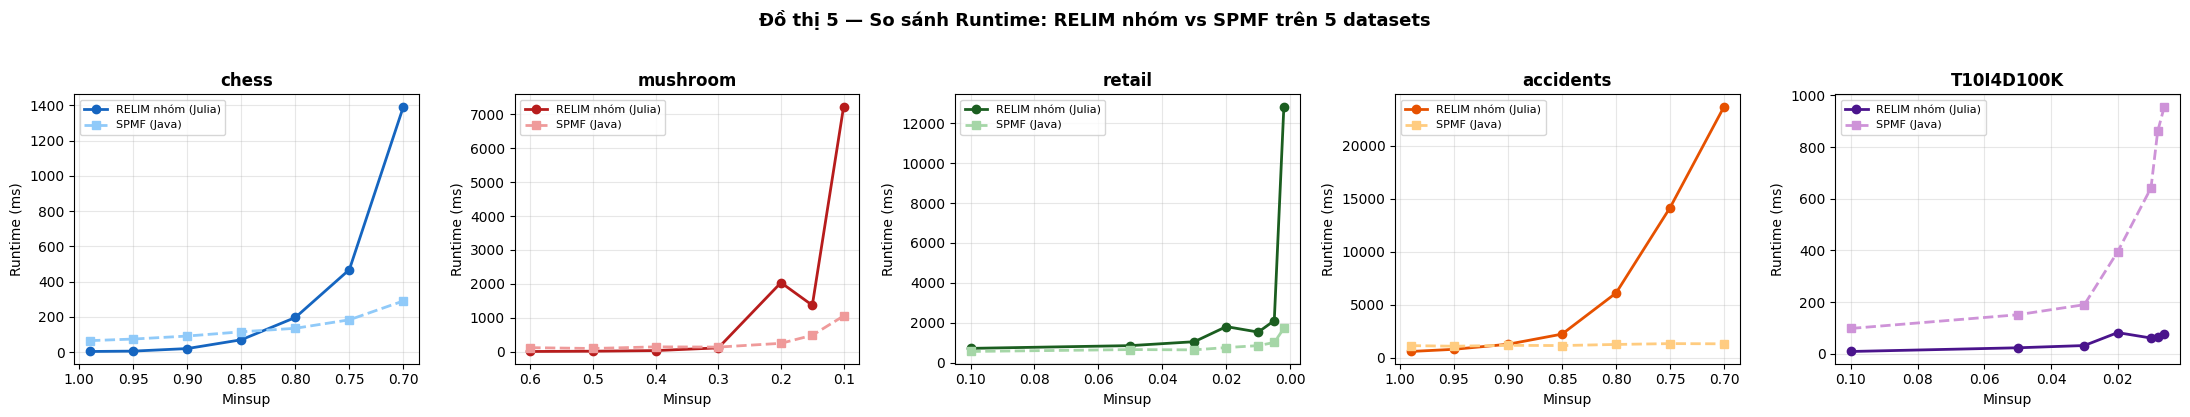

Saved: runtime_relim_vs_spmf.png


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df_ours = pd.read_csv("/kaggle/working/runtime_results.csv")
spmf_exists = os.path.isfile("/kaggle/working/runtime_spmf.csv")
if spmf_exists:
    df_spmf = pd.read_csv("/kaggle/working/runtime_spmf.csv")
    df_spmf = df_spmf[df_spmf["spmf_ms"] >= 0]  # bỏ row lỗi

COLORS_OURS = ["#1565C0","#B71C1C","#1B5E20","#E65100","#4A148C"]
COLORS_SPMF = ["#90CAF9","#EF9A9A","#A5D6A7","#FFCC80","#CE93D8"]
datasets = df_ours["dataset"].unique()

fig, axes = plt.subplots(1, len(datasets), figsize=(22, 4), sharey=False)
for ax, name, c1, c2 in zip(axes, datasets, COLORS_OURS, COLORS_SPMF):
    sub = df_ours[df_ours["dataset"]==name].sort_values("minsup", ascending=False)
    ax.plot(sub["minsup"], sub["runtime_ms"], marker="o", linewidth=2,
            color=c1, label="RELIM nhóm (Julia)")
    if spmf_exists:
        sub_s = df_spmf[df_spmf["dataset"]==name].sort_values("minsup", ascending=False)
        if not sub_s.empty:
            ax.plot(sub_s["minsup"], sub_s["spmf_ms"], marker="s", linewidth=2,
                    linestyle="--", color=c2, label="SPMF (Java)")
    else:
        ax.text(0.5, 0.5, "SPMF data\nkhông có",
                transform=ax.transAxes, ha="center", va="center",
                color="gray", fontsize=9)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Minsup", fontsize=10)
    ax.set_ylabel("Runtime (ms)", fontsize=10)
    ax.invert_xaxis()
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Đồ thị 5 — So sánh Runtime: RELIM nhóm vs SPMF trên 5 datasets",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("/kaggle/working/runtime_relim_vs_spmf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: runtime_relim_vs_spmf.png")


## 5. Số lượng frequent itemsets theo minsup

Vẽ đồ thị số lượng frequent itemsets sinh ra theo minsup giảm dần.

**Nhận xét:**
- Dataset dày (Chess, Accidents, Mushroom): số itemsets tăng rất nhanh khi minsup giảm nhẹ → đường cong dốc đứng.
- Dataset thưa (Retail, T10I4D100K): số itemsets tăng chậm hơn → đường cong thoải hơn.
- Mối quan hệ giữa minsup và output size là **phi tuyến** — giảm minsup một chút có thể nhân đôi hoặc gấp 10 lần số itemsets.

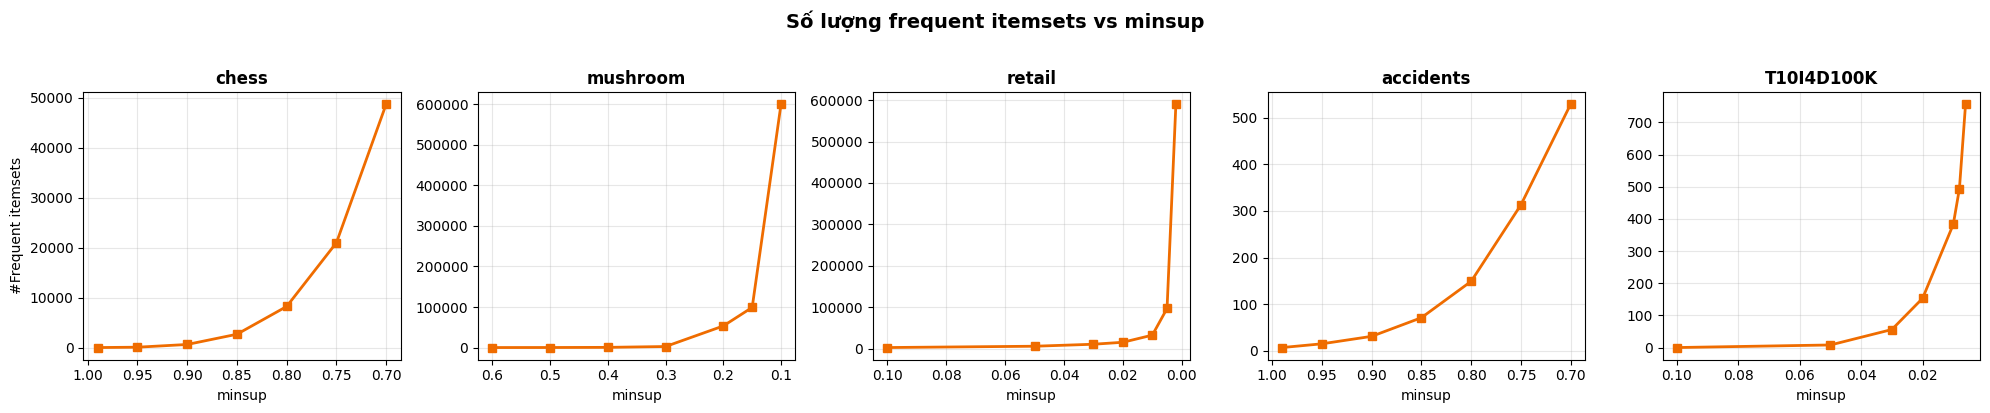

Saved: itemsets_vs_minsup.png


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/working/runtime_results.csv")

datasets = df["dataset"].unique()
fig, axes = plt.subplots(1, len(datasets), figsize=(20, 4))

for ax, name in zip(axes, datasets):
    sub = df[df["dataset"] == name].sort_values("minsup", ascending=False)
    ax.plot(sub["minsup"], sub["n_itemsets"], marker="s", linewidth=2, color="#EF6C00")
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("minsup")
    if name == datasets[0]:
        ax.set_ylabel("#Frequent itemsets")
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3)

plt.suptitle("Số lượng frequent itemsets vs minsup", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/itemsets_vs_minsup.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: itemsets_vs_minsup.png")

## 6. Sử dụng bộ nhớ

Đo mức sử dụng RAM tối đa (peak memory, tính bằng MB) cho mỗi dataset, so sánh giữa:
- **Basic (L1):** `counter_only=false` — giữ toàn bộ node kể cả node rỗng
- **Optimized (L3):** `counter_only=true` — bỏ qua node không cần thiết (Counter-Only Optimization)

Chỉ số đo bằng `@allocated` của Julia — đo tổng số byte được cấp phát trong quá trình chạy.

In [19]:
%%bash
export PATH="$HOME/.juliaup/bin:$PATH"
cd /kaggle/working/relim

julia --project=. -e '
include("src/algorithm/relim.jl")

cases = [
    ("mushroom",   "data/benchmark/mushroom.txt", 0.30),
    ("chess",      "data/benchmark/chess.txt",    0.80),
    ("retail",     "data/benchmark/retail.txt",   0.01),
    ("accidents",  "data/benchmark/accidents.txt",0.90),
    ("T10I4D100K", "data/benchmark/T10I4D100K.txt",0.01),
]

println("=== MEMORY USAGE ===")
println(rpad("Dataset",14), rpad("Minsup",8),
        rpad("Basic (MB)",13), rpad("Opt (MB)",12), "Reduction%")
println("-"^60)

f = open("/kaggle/working/memory_results.csv","w")
println(f, "dataset,minsup,basic_mb,opt_mb")

for (name, path, ms) in cases
    if !isfile(path)
        println(rpad(name,14), "  SKIP")
        continue
    end
    txns = load_spmf(path)
    # warm-up
    relim(txns, ms; counter_only=false)
    relim(txns, ms; counter_only=true)
    GC.gc()
    m_base = @allocated relim(txns, ms; relative=true, counter_only=false)
    GC.gc()
    m_opt  = @allocated relim(txns, ms; relative=true, counter_only=true)
    mb_b = round(m_base/1024^2, digits=2)
    mb_o = round(m_opt/1024^2,  digits=2)
    pct  = round((1 - m_opt/m_base)*100, digits=1)
    println(rpad(name,14), rpad(ms,8), rpad(mb_b,13), rpad(mb_o,12), pct, "%")
    println(f, "$name,$ms,$mb_b,$mb_o")
end
close(f)
println("Saved memory_results.csv")
'


=== MEMORY USAGE ===
Dataset       Minsup  Basic (MB)   Opt (MB)    Reduction%
------------------------------------------------------------
mushroom      0.3     127.8        68.03       46.8%
chess         0.8     347.5        181.53      47.8%
retail        0.01    1039.94      593.88      42.9%
accidents     0.9     269.66       190.29      29.4%
T10I4D100K    0.01    20.71        19.51       5.8%
Saved memory_results.csv


### 6.1 Đồ thị 6 — Biểu đồ Bộ nhớ: Basic (L1) vs Counter-Only Optimized (L3)

Lưu kết quả memory vào CSV rồi vẽ grouped bar chart để so sánh trực quan.

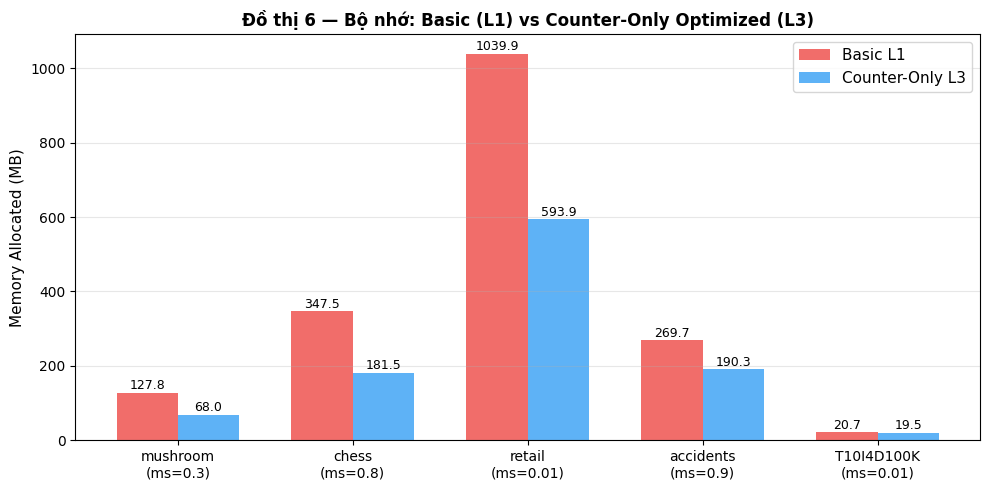

Saved: memory_basic_vs_opt.png


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

mem = pd.read_csv("/kaggle/working/memory_results.csv")

x = np.arange(len(mem))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, mem["basic_mb"],  width, label="Basic L1",    color="#EF5350", alpha=0.85)
bars2 = ax.bar(x + width/2, mem["opt_mb"],    width, label="Counter-Only L3", color="#42A5F5", alpha=0.85)

# Label giá trị trên mỗi cột
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
labels = [f"{row.dataset}\n(ms={row.minsup})" for _, row in mem.iterrows()]
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Memory Allocated (MB)", fontsize=11)
ax.set_title("Đồ thị 6 — Bộ nhớ: Basic (L1) vs Counter-Only Optimized (L3)",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/memory_basic_vs_opt.png", dpi=150)
plt.show()
print("Saved: memory_basic_vs_opt.png")


## 7. Khả năng mở rộng (Scalability)

Đánh giá khả năng mở rộng của RELIM bằng cách chạy trên các tập con của Retail dataset với kích thước tăng dần: 10%, 25%, 50%, 75%, 100%.

Minsup tuyệt đối được giữ cố định (= 1% tổng số giao dịch của tập đầy đủ) để đảm bảo so sánh công bằng.

**Nhận xét mong đợi:** Nếu đường cong gần tuyến tính → thuật toán scale tốt. Nếu cong lên mạnh → chi phí tăng nhanh hơn kích thước dữ liệu.

In [21]:
%%bash
export PATH="$HOME/.juliaup/bin:$PATH"
cd /kaggle/working/relim

julia --project=. -e '
include("src/algorithm/relim.jl")

txns = load_spmf("data/benchmark/retail.txt")
n_total = length(txns)
fixed_abs = max(1, ceil(Int, 0.01 * n_total))
println("Retail: $n_total transactions, fixed minsup_abs=$fixed_abs")

f = open("/kaggle/working/scalability.csv","w")
println(f, "pct,n_trans,runtime_ms")

println("\n=== SCALABILITY ===")
println(rpad("Subset%",10), rpad("#Trans",10), "Runtime (ms)")
println("-"^32)

for p in [0.10, 0.25, 0.50, 0.75, 1.00]
    n = round(Int, p * n_total)
    subset = txns[1:n]
    t = @elapsed relim(subset, fixed_abs; relative=false)
    ms = round(t*1000, digits=2)
    println(rpad("$(round(Int,p*100))%", 10), rpad(n, 10), ms)
    println(f, "$p,$n,$ms")
end
close(f)
'

Retail: 51202 transactions, fixed minsup_abs=513

=== SCALABILITY ===
Subset%   #Trans    Runtime (ms)
--------------------------------
10%       5120      664.06
25%       12800     299.01
50%       25601     629.77
75%       38402     1008.46
100%      51202     2039.96


### 7.1 Đồ thị Scalability (Runtime vs Kích thước CSDL)

**Nhận xét:** Đường cong tuyến tính hay phi tuyến phản ánh khả năng mở rộng của RELIM. Nếu gần tuyến tính → thuật toán scale tốt. Nếu cong lên mạnh → chi phí tăng nhanh hơn kích thước dữ liệu.

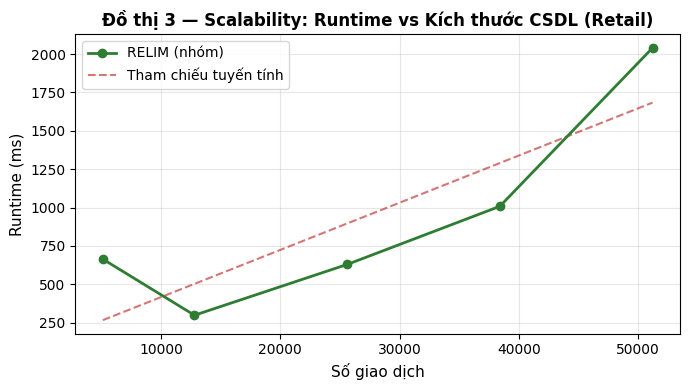

Saved: scalability.png


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

sc = pd.read_csv("/kaggle/working/scalability.csv")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sc["n_trans"], sc["runtime_ms"], marker="o", linewidth=2,
        color="#2E7D32", label="RELIM (nhóm)", zorder=3)

# Vẽ đường tuyến tính tham chiếu
x = sc["n_trans"].values
y = sc["runtime_ms"].values
lin = np.polyfit(x, y, 1)
ax.plot(x, np.polyval(lin, x), linestyle="--", color="#B71C1C",
        alpha=0.6, label="Tham chiếu tuyến tính")

ax.set_xlabel("Số giao dịch", fontsize=11)
ax.set_ylabel("Runtime (ms)", fontsize=11)
ax.set_title("Đồ thị 3 — Scalability: Runtime vs Kích thước CSDL (Retail)",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/scalability.png", dpi=150)
plt.show()
print("Saved: scalability.png")


## 8. Ảnh hưởng của độ dài giao dịch trung bình

Thiết kế thực nghiệm với CSDL tổng hợp: 10,000 giao dịch, 100 items, độ dài trung bình tăng dần từ 5 đến 30.

Minsup cố định ở 10% để cô lập ảnh hưởng của độ dài giao dịch.

**Lý thuyết:** RELIM duyệt theo từng item và xây conditional DB — transaction dài hơn đồng nghĩa với nhiều item hơn trong mỗi conditional DB, dẫn đến chi phí đệ quy tăng theo.

In [23]:
%%bash
export PATH="$HOME/.juliaup/bin:$PATH"
cd /kaggle/working/relim

julia --project=. -e '
using Random, StatsBase
include("src/algorithm/relim.jl")

function gen_db(n_trans, avg_len, n_items, seed=42)
    Random.seed!(seed)
    return [sort(sample(1:n_items, min(max(1,round(Int,avg_len+randn()*2)),n_items), replace=false))
            for _ in 1:n_trans]
end

f = open("/kaggle/working/txlen.csv","w")
println(f, "avg_len,runtime_ms")

println("=== TRANSACTION LENGTH EFFECT ===")
println(rpad("avg_len",10), "Runtime (ms)")
println("-"^25)

for al in [5, 10, 15, 20, 25, 30]
    db = gen_db(10000, al, 100)
    t  = @elapsed relim(db, 0.1; relative=true)
    ms = round(t*1000, digits=2)
    println(rpad(al, 10), ms)
    println(f, "$al,$ms")
end
close(f)
println("Saved txlen.csv")
'

=== TRANSACTION LENGTH EFFECT ===
avg_len   Runtime (ms)
-------------------------
5         1.23
10        8.22
15        23.24
20        37.9
25        59.71
30        76.77
Saved txlen.csv


### 8.1 Đồ thị Ảnh hưởng Độ dài Giao dịch

**Nhận xét:** Đường cong đi lên xác nhận rằng độ dài giao dịch trung bình là một trong các yếu tố ảnh hưởng chính đến hiệu năng RELIM. Transaction dài hơn → conditional DB rộng hơn ở mỗi tầng đệ quy → chi phí tăng phi tuyến, phù hợp phân tích lý thuyết phần 3.1.2.

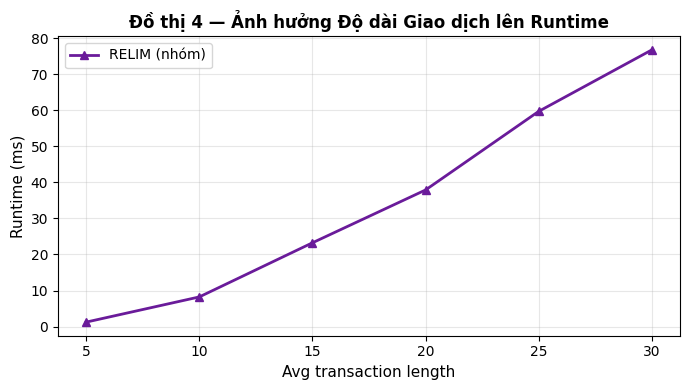

Saved: txlen.png


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

tl = pd.read_csv("/kaggle/working/txlen.csv")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tl["avg_len"], tl["runtime_ms"], marker="^", linewidth=2,
        color="#6A1B9A", label="RELIM (nhóm)")
ax.set_xlabel("Avg transaction length", fontsize=11)
ax.set_ylabel("Runtime (ms)", fontsize=11)
ax.set_title("Đồ thị 4 — Ảnh hưởng Độ dài Giao dịch lên Runtime",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/txlen.png", dpi=150)
plt.show()
print("Saved: txlen.png")
